## LDA y Máquinas de Soporte Vectorial (SVM)

### Representación, clasificación, validación y selección de modelos

Esta notebook integra dos técnicas de clasificación supervisada estudiadas en la teoría: **Análisis Discriminante Lineal (LDA)** y **Máquinas de Soporte Vectorial (SVM)**. El objetivo no es solamente entrenar clasificadores, sino comprender cómo se construye y evalúa un flujo de trabajo completo de aprendizaje automático.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio

from sklearn.datasets import load_wine
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

warnings.filterwarnings('ignore', category=UserWarning)
np.set_printoptions(precision=4, suppress=True)

DATA_DIR = Path('data')
if not DATA_DIR.exists():
    DATA_DIR = Path('.')

print('Directorio de datos:', DATA_DIR.resolve())

Directorio de datos: C:\Users\lukas\OneDrive\Escritorio\Nu-ez_Segovia-Aprendizaje_automatico\Trabajo_practico_6\data


In [2]:
# Funciones auxiliares provistas para visualización

def plot_labeled_points(X, y, title, xlabel='x1', ylabel='x2'):
    plt.figure(figsize=(7, 5))
    markers = ['o', 's', '^', 'v', 'D', 'P']
    for idx, label in enumerate(np.unique(y)):
        plt.scatter(
            X[y == label, 0],
            X[y == label, 1],
            marker=markers[idx % len(markers)],
            alpha=0.75,
            label=f'Clase {label}',
        )
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()


def plot_decision_boundary(model, X, y, title, show_support=True, step=0.02):
    x1_min, x1_max = X[:, 0].min() - 0.1 * np.ptp(X[:, 0]), X[:, 0].max() + 0.1 * np.ptp(X[:, 0])
    x2_min, x2_max = X[:, 1].min() - 0.1 * np.ptp(X[:, 1]), X[:, 1].max() + 0.1 * np.ptp(X[:, 1])

    n_grid = 260
    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, n_grid),
        np.linspace(x2_min, x2_max, n_grid),
    )
    grid = np.column_stack([xx1.ravel(), xx2.ravel()])
    pred = model.predict(grid).reshape(xx1.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx1, xx2, pred, alpha=0.18)
    plt.contour(xx1, xx2, pred, levels=np.unique(y)[:-1] + 0.5, linewidths=1.2)

    markers = ['o', 's', '^', 'v']
    for idx, label in enumerate(np.unique(y)):
        plt.scatter(
            X[y == label, 0],
            X[y == label, 1],
            marker=markers[idx % len(markers)],
            alpha=0.8,
            label=f'Clase {label}',
        )

    if show_support and hasattr(model, 'named_steps') and 'svc' in model.named_steps:
        support_idx = model.named_steps['svc'].support_
        plt.scatter(
            X[support_idx, 0],
            X[support_idx, 1],
            s=120,
            facecolors='none',
            linewidths=1.6,
            label='Vectores de soporte',
        )

    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.legend()
    plt.show()

## Parte A. Análisis Discriminante Lineal (LDA)

LDA puede utilizarse de dos formas relacionadas:

1. como **clasificador lineal supervisado**;
2. como **transformación supervisada para reducción de dimensionalidad**.

En esta práctica se trabajará con el **Wine dataset** de 3 clases.

### 1. Criterio de Fisher

La idea del discriminante lineal de Fisher es encontrar una dirección de proyección en la que:

- las muestras de una misma clase queden relativamente **compactas**
- las medias de clases diferentes queden **separadas**

Una forma de expresar esta idea es mediante el cociente:

$$
J(\mathbf{w}) = \frac{\mathbf{w}^T S_B \mathbf{w}}{\mathbf{w}^T S_W \mathbf{w}},
$$

donde $S_B$ representa la dispersión **entre clases** y $S_W$ la dispersión **intra-clase**.

En el caso multiclase, LDA busca varias direcciones discriminantes. 

**Número máximo de componentes discriminantes**

Si el dataset tiene $p$ características y $c$ clases, LDA puede obtener como máximo

$$ \min(p,c-1) $$

direcciones discriminantes.

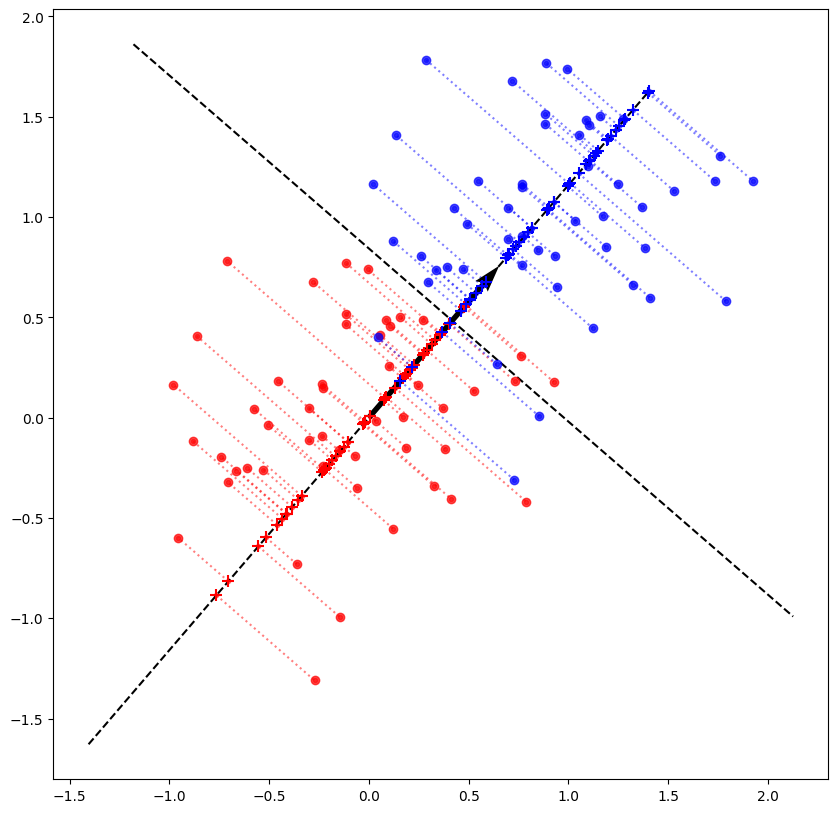

La imagen muestra que no cualquier dirección de proyección separa igualmente bien las clases. LDA busca las direcciones que conservan información relevante para discriminar las etiquetas.

##### Supuestos teóricos de LDA

En su formulación clásica, LDA supone que las variables discriminantes son cuantitativas y que las clases son mutuamente excluyentes. Además, se asume aproximadamente normalidad multivariante dentro de cada clase y matrices de covarianza similares entre clases. También debe evitarse dependencia lineal exacta entre variables.

Estos supuestos ayudan a justificar el modelo probabilístico que conduce a fronteras lineales. En la práctica, LDA puede seguir funcionando razonablemente cuando los supuestos se cumplen solo de manera aproximada.

### **Análisis:**

Teniendo en cuenta el la explicación teorica, y el análisis realizado en la actividad, se sabe ahora que:

Si el dataset tiene $p$ variables predictoras y $c$ clases, el número máximo de direcciones discriminantes es:

$$
\min(p,c-1)
$$

En este caso, el dataset Wine posee 13 variables y 3 clases, por lo que el número máximo de componentes discriminantes es:

$$
\min(13,3-1)=2
$$

#### 2. Carga y exploración del Wine dataset

**Consigna.** Cargue el dataset y responda:

1. ¿Cuántas muestras, variables predictoras y clases tiene?
2. ¿Las clases tienen exactamente la misma cantidad de muestras?

In [3]:
# Código provisto
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
class_names = wine.target_names

print('X:', X.shape)
print('y:', y.shape)
print('Clases:', np.unique(y))
print('Cantidad por clase:')
print(pd.Series(y).value_counts().sort_index())

X: (178, 13)
y: (178,)
Clases: [0 1 2]
Cantidad por clase:
0    59
1    71
2    48
Name: count, dtype: int64


El dataset Wine contiene:

178 muestras.
13 variables predictoras.
3 clases.

Las clases no tienen exactamente la misma cantidad de muestras:

| Clase | Cantidad de muestras |
|:-----:|:--------------------:|
| 0     | 59                   |
| 1     | 71                   |
| 2     | 48                   |   

Por lo tanto, existe una diferencia en la cantidad de muestras entre las clases, aunque se observa que las cantidades son lo suficientemente parejas como para que el algoritmo pueda aprender los patrones de los tres tipos de vino sin sesgarse hacia uno solo.

#### 3. División en entrenamiento y prueba

Para esta primera parte se reservará un conjunto de prueba que permanecerá fuera del entrenamiento. Utilice 

- `test_size=0.30`
- `random_state=42`
- `stratify=y`.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)


#### 4. Estandarización para la implementación manual

Para reproducir de manera estable los pasos matriciales de LDA y facilitar la comparación de magnitudes, se escalan las características.

> **Importante.** A diferencia de KNN y SVM, el LDA clásico no depende de distancias euclidianas entre atributos en la misma forma y, en teoría, una transformación lineal invertible de escala no debería cambiar esencialmente la regla discriminante. Aquí se escala principalmente por estabilidad numérica y para mantener un flujo de trabajo homogéneo.

In [5]:
# Escale train y test
scaler= StandardScaler()
X_train_std =scaler.fit_transform(X_train)
X_test_std= scaler.transform(X_test)


#### 5. Implementación guiada de LDA como reducción de dimensionalidad

En esta sección se provee el código. 

El objetivo es seguir el procedimiento y poder interpretar qué representa cada cantidad.

##### 5.1 Vectores de medias por clase

Para cada clase $i$ se calcula su vector de medias $\mathbf{m}_i$.

In [6]:
# Código provisto
classes = np.unique(y_train)
mean_vectors = []

for label in classes:
    mean_vec = X_train_std[y_train == label].mean(axis=0)
    mean_vectors.append(mean_vec)
    print(f'Clase {label} - vector de medias:')
    print(mean_vec)
    print()

Clase 0 - vector de medias:
[ 0.9585 -0.322   0.3219 -0.7607  0.4346  0.8574  0.9809 -0.4969  0.4261
  0.2418  0.4251  0.7139  1.1879]

Clase 1 - vector de medias:
[-0.8829 -0.3073 -0.4875  0.2536 -0.323  -0.0632  0.0417 -0.0784  0.185
 -0.8575  0.4598  0.2946 -0.7075]

Clase 2 - vector de medias:
[ 0.1468  0.8657  0.3387  0.5609 -0.0506 -0.9695 -1.282   0.7362 -0.8096
  0.9987 -1.2249 -1.3334 -0.4039]



##### 5.2 Matriz de dispersión intra-clase $S_W$

La matriz de dispersión intra-clase acumula la variabilidad de las muestras alrededor de la media de su propia clase:

$$
S_W = \sum_{i=1}^{c}\sum_{\mathbf{x}\in D_i}
(\mathbf{x}-\mathbf{m}_i)(\mathbf{x}-\mathbf{m}_i)^T.
$$

In [7]:
# Código provisto
d = X_train_std.shape[1]
S_W = np.zeros((d, d))

for label, mean_vec in zip(classes, mean_vectors):
    X_class = X_train_std[y_train == label]
    centered = X_class - mean_vec
    S_W += centered.T @ centered

print('Dimensión de S_W:', S_W.shape)

Dimensión de S_W: (13, 13)


##### 5.3 Matriz de dispersión entre-clases $S_B$

La dispersión entre clases se calcula respecto de la media global $\mathbf{m}$:

$$
S_B = \sum_{i=1}^{c} n_i(\mathbf{m}_i-\mathbf{m})(\mathbf{m}_i-\mathbf{m})^T.
$$

El factor $n_i$ pondera la contribución de cada clase según su cantidad de muestras.

In [8]:
# Código provisto
mean_overall = X_train_std.mean(axis=0)
S_B = np.zeros((d, d))

for label, mean_vec in zip(classes, mean_vectors):
    n_i = np.sum(y_train == label)
    mean_diff = (mean_vec - mean_overall).reshape(d, 1)
    S_B += n_i * (mean_diff @ mean_diff.T)

print('Dimensión de S_B:', S_B.shape)

Dimensión de S_B: (13, 13)


##### 5.4 Problema de autovalores y matriz de proyección

La formulación clásica conduce a estudiar las direcciones principales asociadas a:

$$
S_W^{-1}S_B.
$$

En el código se utiliza la pseudoinversa de $S_W$ en lugar de formar explícitamente una inversa numérica. 

Luego se ordenan los autovalores de mayor a menor y se seleccionan los dos autovectores principales.

In [9]:
# Código provisto
matrix_lda = np.linalg.pinv(S_W) @ S_B
eigen_vals, eigen_vecs = np.linalg.eig(matrix_lda)

eigen_pairs = [
    (eigen_vals[i].real, eigen_vecs[:, i].real)
    for i in range(len(eigen_vals))
]
eigen_pairs = sorted(eigen_pairs, key=lambda pair: pair[0], reverse=True)

print('Mayores autovalores:')
for value, _ in eigen_pairs:
    print(f'{value:.6f}')

W = np.column_stack([eigen_pairs[0][1], eigen_pairs[1][1]])
print('\nDimensión de W:', W.shape)

Mayores autovalores:
9.932534
4.960436
0.000000
0.000000
0.000000
0.000000
0.000000
0.000000
0.000000
0.000000
-0.000000
-0.000000
-0.000000

Dimensión de W: (13, 2)


##### 5.5 Proyección al espacio LDA

La transformación se obtiene mediante:

$$
X_{LDA}=XW.
$$

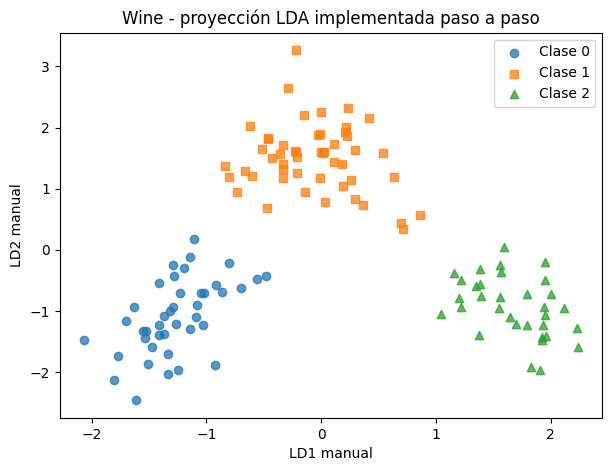

In [10]:
# Código provisto
X_train_lda_manual = X_train_std @ W
X_test_lda_manual = X_test_std @ W

plt.figure(figsize=(7, 5))
markers = ['o', 's', '^']
for idx, label in enumerate(classes):
    plt.scatter(
        X_train_lda_manual[y_train == label, 0],
        X_train_lda_manual[y_train == label, 1],
        marker=markers[idx],
        alpha=0.75,
        label=f'Clase {label}',
    )
plt.xlabel('LD1 manual')
plt.ylabel('LD2 manual')
plt.title('Wine - proyección LDA implementada paso a paso')
plt.legend()
plt.show()

**Preguntas de análisis**

1. ¿Qué dimensión tiene $W$? ¿Por qué? 
2. ¿Por qué aparecen solamente dos autovalores importantes aunque el dataset tenga 13 variables?¿cuántas dimensiones tiene el espacio discriminante?
3. ¿Qué significa geométricamente que las clases se separen mejor después de la proyección?

##### **1. Dimensión de la matriz de proyección $W$**

La matriz $W$ contiene los vectores propios asociados a las direcciones discriminantes seleccionadas.

Como se seleccionan las dos direcciones discriminantes principales y el dataset posee 13 variables:

$$
W\in\mathbb{R}^{13\times2}
$$

La proyección se realiza mediante:

$$
X_{LDA}=XW
$$

Por lo tanto, los datos originales pasan de tener 13 dimensiones a tener solamente 2 dimensiones.

##### **2. ¿Por qué aparecen solamente dos autovalores importantes?**

Aunque el dataset tiene 13 variables, LDA no puede generar una cantidad cualquiera de dimensiones discriminantes.

Como ya se dijo anteriormente, el máximo número de dimensiones discriminantes está limitado por:

$$
\min(p,c-1)
$$

En este caso:

$$
\min(13,3-1)=2
$$

$S_B$ se contruye con c = 3 vectores de medias centrados en la media global, que son linealmente dependientes, así que tiene rango a lo sumo c-1 = 2. Por eso solo dos autovalores son distintos de cero (9.93 y 4.96) y el resto son ≈ 0. El espacio discriminante tiene entonces 2 dimensiones.

Las restantes dimensiones no aportan nuevas direcciones independientes para separar las tres clases. 

##### **3. Interpretación geométrica de la proyección**

La proyección LDA busca una representación de los datos donde las clases estén separadas de la mejor manera posible.

Geométricamente, esto significa transformar los puntos originales del espacio de 13 dimensiones hacia un espacio de solamente 2 dimensiones, intentando conservar las direcciones que contienen mayor información para distinguir las clases.

Si después de la proyección los grupos aparecen más separados y con menor solapamiento, significa que las direcciones seleccionadas son útiles para la discriminación entre clases.

#### 6. LDA con scikit-learn como transformación supervisada

Utilice `LinearDiscriminantAnalysis(n_components=2)` y compare la representación obtenida con la implementación manual.

Dimensión train transformado: (124, 2)
Dimensión test transformado: (54, 2)
Explained variance ratio: [0.6669 0.3331]
Suma explained variance ratio: 1.0


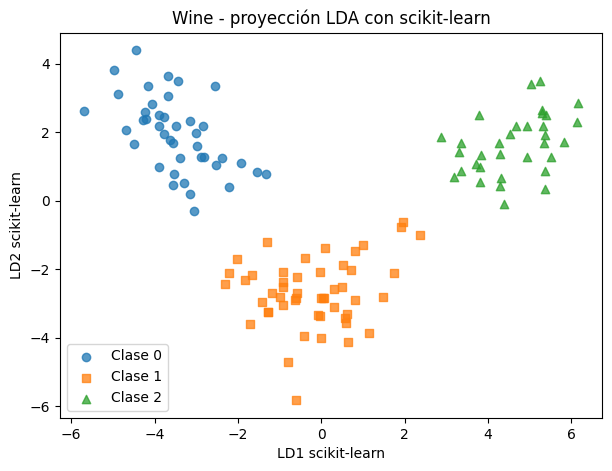

In [11]:
lda_sklearn = LinearDiscriminantAnalysis(n_components=2)

X_train_lda_sklearn =  lda_sklearn.fit_transform(X_train_std, y_train)
X_test_lda_sklearn = lda_sklearn.transform(X_test_std)

print('Dimensión train transformado:', X_train_lda_sklearn.shape)
print('Dimensión test transformado:', X_test_lda_sklearn.shape)
print('Explained variance ratio:', lda_sklearn.explained_variance_ratio_)
print('Suma explained variance ratio:', lda_sklearn.explained_variance_ratio_.sum())

plt.figure(figsize=(7, 5))
markers = ['o', 's', '^']

for idx, label in enumerate(np.unique(y_train)):
    plt.scatter(
        X_train_lda_sklearn[y_train == label, 0],
        X_train_lda_sklearn[y_train == label, 1],
        marker=markers[idx],
        alpha=0.75,
        label=f'Clase {label}',
    )

plt.xlabel('LD1 scikit-learn')
plt.ylabel('LD2 scikit-learn')
plt.title('Wine - proyección LDA con scikit-learn')
plt.legend()
plt.show()

**Investigue:**

1. ¿La proyección de scikit-learn debe ser idéntica punto por punto a la implementación manual?
2. ¿Qué significan los valores de `explained_variance_ratio_` del LDA de scikit-learn?
3. ¿Por qué el signo de un eje discriminante puede aparecer invertido sin que exista un error?

#### **Investigación**

**1. ¿La proyección de scikit-learn debe ser idéntica punto por punto a la implementación manual?**

No necesariamente. Ambas implementaciones buscan las mismas direcciones discriminantes, pero la representación numérica puede no coincidir exactamente punto por punto.

Esto debido a que los vectores propios utilizados como ejes discriminantes pueden estar normalizados de manera diferente. Además, los vectores propios están definidos salvo un factor de escala y un cambio de signo.

Por ejemplo, si una implementación obtiene un eje: **w**

Y la otra obtiene:**-w**

Ambos representan exactamente la misma dirección en el espacio, pero los valores proyectados tendrán el signo contrario.

Por lo que si las coordenadas obtenidas por ambas implementaciones no son idénticas no significa que una de ellas sea incorrecta. Lo importante es que ambas representaciones conserven la misma estructura de separación entre las clases.

**2. ¿Qué significan los valores de explained_variance_ratio_ del LDA de scikit-learn?**

El atributo explained_variance_ratio_ indica la proporción relativa de la capacidad discriminante asociada a cada componente de LDA.

En nuestro caso se obtuvieron aproximadamente:

$$
[0.6669,\ 0.3331]
$$

Por lo tanto, la primera componente discriminante representa aproximadamente el 66.69 % de la capacidad discriminante y la segunda aproximadamente el 33.31 %.

La suma de ambas componentes es:

$$
0.6669+0.3331=1
$$

es decir, aproximadamente el 100 %.

Esto es coherente con que el problema tiene tres clases y, por lo tanto, como máximo existen dos dimensiones discriminantes. En consecuencia, las dos componentes seleccionadas contienen toda la información discriminante disponible en este caso.

3. ¿Por qué el signo de un eje discriminante puede aparecer invertido sin que exista un error?

El signo de un vector propio no está determinado de manera única.

Si $\mathbf{w}$ es un vector propio de $S_W^{-1}S_B$ asociado a $\lambda$:

$$S_W^{-1}S_B\,\mathbf{w}=\lambda\,\mathbf{w}$$

Por linealidad, $S_W^{-1}S_B\,(-\mathbf{w})=-S_W^{-1}S_B\,\mathbf{w}=\lambda\,(-\mathbf{w})$, es decir, $-\mathbf{w}$ también es vector propio con el mismo autovalor

Por lo tanto, si una implementación obtiene w y otra obtiene -w, ambas están utilizando la misma dirección discriminante, solamente orientada en sentidos opuestos.

Esto también modifica el signo de las coordenadas proyectadas. Por ejemplo: 

Xw   y   X(-w) = -Xw

Representan la misma proyección geométrica, pero con el eje invertido.

Por esto al comparar la implementación manual con scikit-learn, no es necesario que los signos de los ejes coincidan. Lo importante es que la separación relativa de las clases sea equivalente.

#### 7. LDA como clasificador

Hasta aquí LDA se utilizó como transformación. Ahora úselo directamente como clasificador y evalúe su desempeño sobre el conjunto de prueba reservado. Calcule también la matriz de confusión.

Accuracy en test: 0.9815
Muestras Incorrectamente Clasificadas: 1


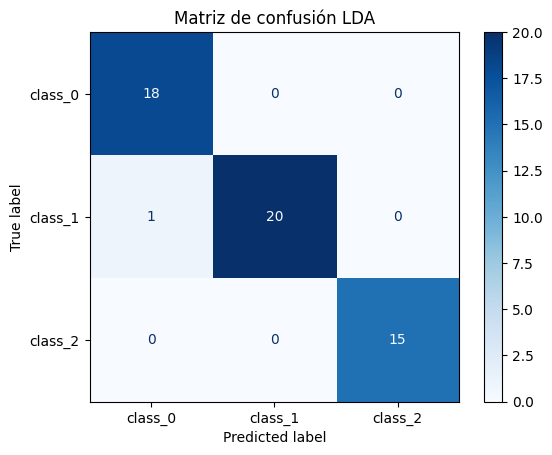

In [12]:
lda_clf= LinearDiscriminantAnalysis()
lda_clf.fit(X_train, y_train)

y_pred_lda = lda_clf.predict(X_test)

acc_lda_test= accuracy_score(y_test, y_pred_lda)
cm_lda= confusion_matrix(y_test, y_pred_lda)

print(f'Accuracy en test: {acc_lda_test:.4f}')
print(f'Muestras Incorrectamente Clasificadas:', np.sum(y_test != y_pred_lda))

ConfusionMatrixDisplay(
    confusion_matrix=cm_lda, display_labels=class_names
).plot(cmap='Blues')

plt.title('Matriz de confusión LDA')
plt.show()

**Preguntas de análisis**

1. ¿Cuántas muestras fueron clasificadas incorrectamente?
2. ¿Qué diferencia conceptual existe entre usar LDA con `transform()` y usarlo con `predict()`?
3. ¿La frontera de decisión de LDA es lineal o no lineal?

**1. Muestras clasificadas incorrectamente**

Hubo exactamente 1 muestra clasificada de forma incorrecta al evaluar el modelo sobre el conjunto de prueba.  

**2. Diferencia conceptual entre transform() y predict() en LDA**

* Con transform(): LDA se utiliza como una técnica supervisada de reducción de dimensionalidad. Su función es encontrar nuevas direcciones de proyección (componentes discriminantes). Lo hace buscando el ángulo de visión perfecto que garantice la máxima separación inter-clase (que los grupos diferentes queden lo más lejos posible entre sí) y la mínima dispersión intra-clase (que los puntos que pertenecen al mismo grupo queden agrupados de forma muy compacta).  

* Con predict(): LDA se emplea directamente como un clasificador lineal supervisado. En lugar de solo proyectar los datos, el algoritmo utiliza lo aprendido para establecer una frontera de separación matemática. Evalúa geométricamente de qué lado de la frontera cae una nueva observación para predecir su clase.  

**3. Tipo de frontera de decisión**

La frontera de decisión de LDA es lineal. Los supuestos teóricos del algoritmo (como la normalidad multivariante dentro de cada clase y matrices de covarianza similares) justifican un modelo probabilístico que conduce matemáticamente a la creación de fronteras lineales para separar los grupos. 

#### 8. Validación cruzada:

Una única división entrenamiento/prueba puede producir un resultado dependiente de qué muestras quedaron en cada subconjunto. La **validación cruzada de $k$ particiones** repite el proceso $k$ veces: cada partición actúa una vez como validación y las restantes como entrenamiento.

En esta sección se utilizarán 5 particiones. El conjunto de prueba reservado anteriormente **no participa** de esta validación cruzada.

**Consigna.** 

Calcule los cinco accuracies de validación cruzada de LDA sobre `X_train, y_train` usando `cross_val_score` de scikit-learn y reporte media y desviación estándar.

In [13]:
lda_cv_model = LinearDiscriminantAnalysis()

scores_lda= cross_val_score(lda_cv_model, X_train, y_train, cv=5, scoring='accuracy')

print('Accuracy de cada fold:', scores_lda)
print(f'media: {scores_lda.mean():.4f}')
print(f'Desviacion estandar {scores_lda.std():.4f}')

Accuracy de cada fold: [0.96 0.96 1.   1.   1.  ]
media: 0.9840
Desviacion estandar 0.0196


**Preguntas de análisis**

1. ¿Por qué aparecen cinco valores de accuracy?
2. ¿Qué representa la media de esos valores?
3. ¿Qué información aporta la desviación estándar?
4. ¿Validación cruzada y búsqueda de hiperparámetros son lo mismo?

**1. ¿Por qué aparecen cinco valores de accuracy?**

Porque se aplicó un protocolo de validación cruzada en el que los datos se dividen en diferentes particiones (en este caso cinco). El modelo se entrena y evalúa cinco veces alternando los datos, lo que genera un valor de exactitud por cada repetición del ciclo.

**2. ¿Qué representa la media de esos valores?**

La media representa la estimación del desempeño global del modelo. Al promediar los resultados de todas las particiones se obtiene una métrica mucho más robusta y realista sobre cómo se comportará el clasificador frente a datos nuevos que el modelo nunca ha visto.  

**3. ¿Qué información aporta la desviación estándar?**

Captura cuánto cambia el desempeño del algoritmo si se entrena con diferentes conjuntos de entrenamiento. Una desviación estándar baja indica que el modelo es estable, mientras que una alta significa que su rendimiento es impredecible y depende demasiado de cómo se hayan partido los datos.  

**4. ¿Validación cruzada y búsqueda de hiperparámetros son lo mismo?**

No, cumplen roles distintos aunque trabajan en conjunto. Los hiperparámetros (como la $K$ en KNN, o $C$ y $\gamma$ en SVM) son configuraciones que el algoritmo no aprende directamente en el entrenamiento y deben elegirse de forma externa. Por otro lado, la validación cruzada es un protocolo de evaluación. En la práctica, se utiliza la validación cruzada para probar múltiples hiperparámetros y encontrar la mejor combinación de manera segura, ajustando el pipeline completo en cada partición para evitar la fuga de datos.

#### 9. Efecto del escalado en LDA
Compare mediante validación cruzada LDA con y sin `StandardScaler`.

In [14]:
lda_sin_escalar = LinearDiscriminantAnalysis()

score_lda_sin_escalar= cross_val_score(lda_sin_escalar, X_train, y_train, cv=5, scoring='accuracy')
print('LDA Sin Escalado')
print('Accuracy de cada fold:', score_lda_sin_escalar)
print(f'media: {score_lda_sin_escalar.mean():.4f}')
print(f'Desviacion estandar {score_lda_sin_escalar.std():.4f}')
print('\n')

lda_con_escalado= Pipeline([('scaler', StandardScaler()), ('lda', LinearDiscriminantAnalysis())]
)
score_lda_con_escalado= cross_val_score(lda_con_escalado, X_train, y_train, cv=5, scoring='accuracy')
print('LDA Con escalado')
print('Accuracy de cada fold:', score_lda_con_escalado)
print(f'media: {score_lda_con_escalado.mean():.4f}')
print(f'Desviacion estandar {score_lda_con_escalado.std():.4f}')


LDA Sin Escalado
Accuracy de cada fold: [0.96 0.96 1.   1.   1.  ]
media: 0.9840
Desviacion estandar 0.0196


LDA Con escalado
Accuracy de cada fold: [0.96 0.96 1.   1.   1.  ]
media: 0.9840
Desviacion estandar 0.0196


**Análisis del escalado en LDA**

Los resultados en este caso son iguales ¿Por qué? Porque LDA es matemáticamente invariante a la escala. Al aplicar el escalado, todas las variables se modifican proporcionalmente, por lo que la frontera matemática que dibuja el algoritmo para separar las clases sigue siendo exactamente la misma.

**¿Por qué usar StandardScaler de todas formas?**

* **Estabilidad numérica:** El cálculo de LDA involucra inversiones de matrices y problemas de autovalores. Si las variables originales tienen magnitudes muy extremas (números gigantes mezclados con números diminutos), la computadora puede sufrir errores de redondeo o inestabilidad al hacer las operaciones matriciales. Escalar los datos previene esto.

* Estandarización: Otros algoritmos (como SVM o KNN) sí requieren normalización de forma obligatoria para funcionar bien. Usar siempre el escalador permite comparar todos los modelos bajo las mismas reglas sin que ninguno falle.

## Parte B. Máquinas de Soporte Vectorial (SVM)

Una SVM lineal busca un hiperplano de separación:

$$
\mathbf{w}^T\mathbf{x}+b=0
$$

que separe las clases maximizando el **margen**. Los puntos más próximos a la frontera son los **vectores de soporte** y determinan la solución.

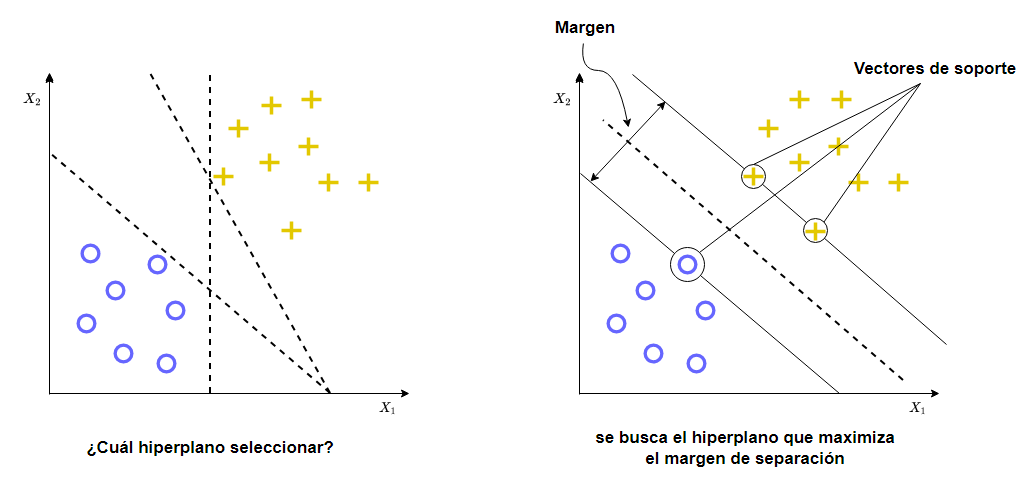

#### 10. Margen blando y parámetro $C$

Cuando los datos contienen ruido, solapamiento e instancias atípicas, exigir separación perfecta puede producir una frontera poco generalizable. La SVM de margen blando introduce variables de holgura $\xi_i$ y resuelve conceptualmente un compromiso del tipo:

$$
\min_{\mathbf{w},b,\xi}\; \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_i \xi_i.
$$

El hiperparámetro $C$ controla cuánto se penalizan las violaciones del margen:

- **$C$ grande:** penaliza fuertemente los errores; la frontera intenta ajustarse más a las muestras de entrenamiento;
- **$C$ pequeño:** tolera más violaciones y favorece un margen más amplio.

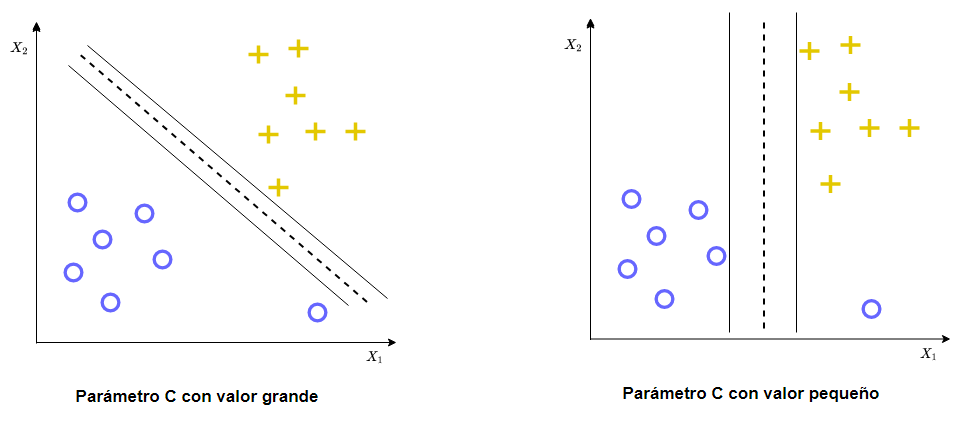

> **Escalado en SVM.** SVM es sensible a la escala de los atributos porque tanto el margen como, en kernels como RBF, las distancias entre muestras dependen de la geometría del espacio. Por eso se utilizará `StandardScaler` dentro de un `Pipeline`.

#### 11. Dataset 1: efecto de $C$ y de una observación atípica

El primer dataset es bidimensional y aproximadamente linealmente separable, pero contiene una observación atípica.

**Consigna.** 

Entrene SVM lineales con $C\in\{0.01,1,100\}$ y analice cómo cambia la frontera, el número de vectores de soporte y el ajuste al dato atípico.

Use la función `plot_decision_boundary` provista al inicio de la notebook

Dimensiones: (51, 2)
Clases: [0 1]


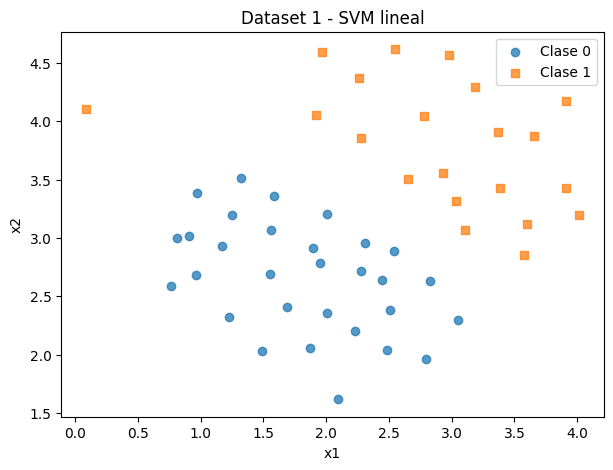

In [15]:
# Código provisto
mat1 = sio.loadmat(DATA_DIR / 'data1.mat')
X_svm1 = mat1['X']
y_svm1 = mat1['y'].ravel()

print('Dimensiones:', X_svm1.shape)
print('Clases:', np.unique(y_svm1))
plot_labeled_points(X_svm1, y_svm1, 'Dataset 1 - SVM lineal')

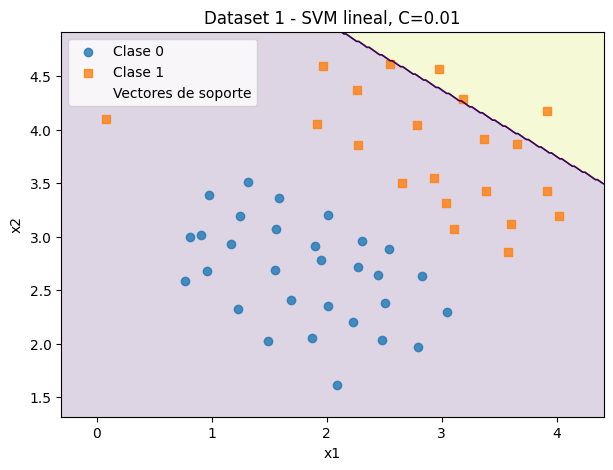

C = 0.01 | vectores de soporte: 43 | accuracy train: 0.647


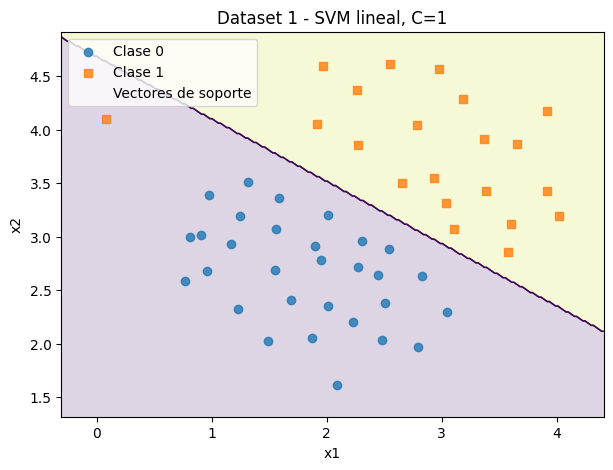

C = 1 | vectores de soporte: 11 | accuracy train: 0.980


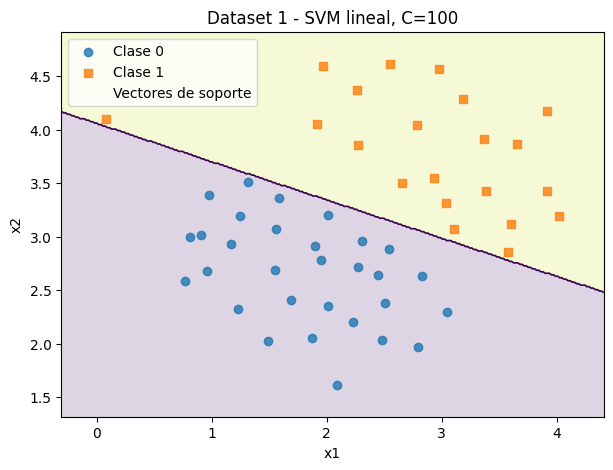

C = 100 | vectores de soporte: 3 | accuracy train: 1.000


In [29]:
valores_C = [0.01, 1, 100]

for c in valores_C:
  svm_lineal =Pipeline([
      ('scaler', StandardScaler()),
      ('svc', SVC(kernel='linear', C=c))
       ])
  
  svm_lineal.fit(X_svm1, y_svm1)
  svc = svm_lineal.named_steps['svc']

  plot_decision_boundary(svm_lineal, X_svm1, y_svm1, f'Dataset 1 - SVM lineal, C={c}')
  print(f'C = {c} | vectores de soporte: {svc.support_.size} | accuracy train: {svm_lineal.score(X_svm1, y_svm1):.3f}')

**Preguntas de análisis**

1. ¿Qué ocurre con el margen cuando $C$ disminuye?.
- El margen se ensancha y se vuelve más "blando". Con C = 0.01 la penalización por violar el margen es tan baja que casi todas las muestras quedan dentro del margen o del lado equivocado, la frontera se desplaza hacia la esquina superior derecha y clasifica mal a la mayoría de la clase 1. No ignora solo al outlier, el modelo subajusta. Con C = 1 se obtiene el mejor equilibrio, la masa principal de ambas clases bien separada  y solo el outlier mal clasificado.

2. ¿Qué ocurre con el ajuste al outlier cuando $C$ aumenta?
- El modelo sacrifica la amplitud del margen para forzar la clasificación correcta del valor atípico. Al elevar la penalización a C=100, la frontera de decisión se mueve drásticamente para asegurar que el cuadrado naranja quede en la región correcta, estrechando el margen y acercando peligrosamente la frontera al resto de los datos.

3. ¿Qué riesgo aparece con un $C$ excesivamente grande?
- El risgo principal es el sobreajuste (overfitting). Al obligar a la SVM a clasificar perfectamente cada punto, el hiperplano se vuelve extremadamente sensible al ruido y a las anomalías puntuales del conjunto de entrenamiento, perdiendo su capacidad de generalizar ante nuevas muestras.

4. ¿Por qué no debería elegirse $C$ solamente observando el accuracy de entrenamiento?
- Basarse unicamente en el entrenamiento favorecere siempre configuraciones con un C muy alto que alcanzan un accuracy perfecto memorizando los outliers. El valor de C ideal que equilibra el sesgo y la varianza (como se observa en la transición hacia C=1) solo puede encontrarse midiendo el desempeño en datos no vistos con validación cruzada.

#### 12. Dataset 2: SVM con kernel RBF y efecto de $\gamma$

Cuando las clases no son separables mediante un hiperplano en el espacio original, una SVM puede utilizar un **kernel**. El kernel RBF o Gaussiano se define como:

$$
K(\mathbf{x},\mathbf{z})=\exp\left(-\gamma\|\mathbf{x}-\mathbf{z}\|^2\right).
$$

El parámetro $\gamma$ controla el alcance de influencia de cada muestra:

- $\gamma$ pequeño: influencia más amplia y frontera más suave;
- $\gamma$ grande: influencia más local y frontera potencialmente más compleja.

**Consigna.** 

Mantenga $C=1$ y compare $\gamma\in\{0.01,1,100\}$.

Use la función `plot_decision_boundary` provista al inicio de la notebook

Dimensiones: (863, 2)
Cantidad por clase: [383 480]


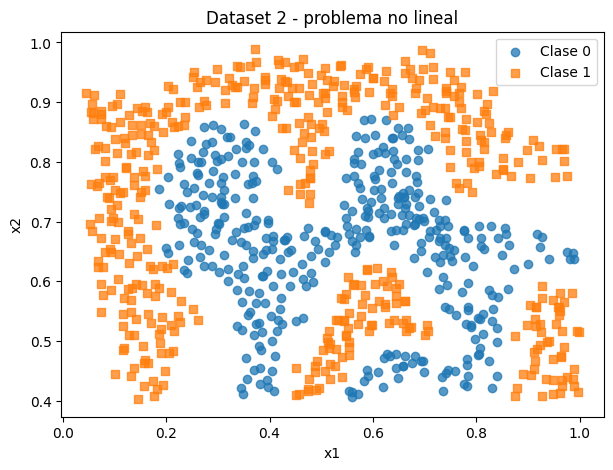

In [17]:
# Código provisto: carga y visualización
mat2 = sio.loadmat(DATA_DIR / 'data2.mat')
X_svm2 = mat2['X']
y_svm2 = mat2['y'].ravel()

print('Dimensiones:', X_svm2.shape)
print('Cantidad por clase:', np.bincount(y_svm2.astype(int)))
plot_labeled_points(X_svm2, y_svm2, 'Dataset 2 - problema no lineal')

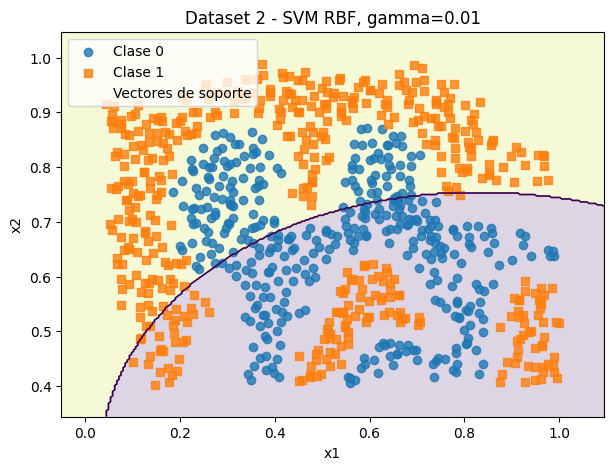

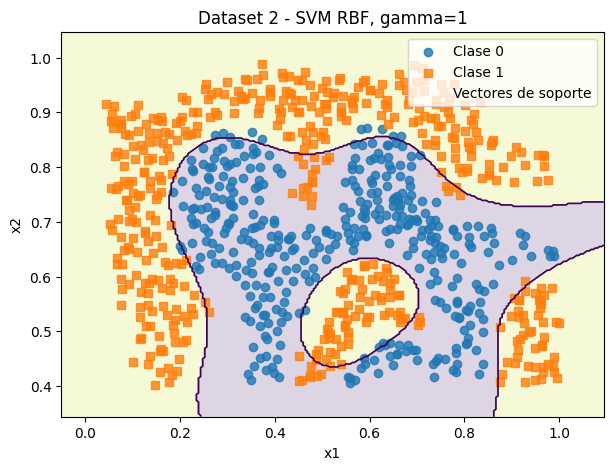

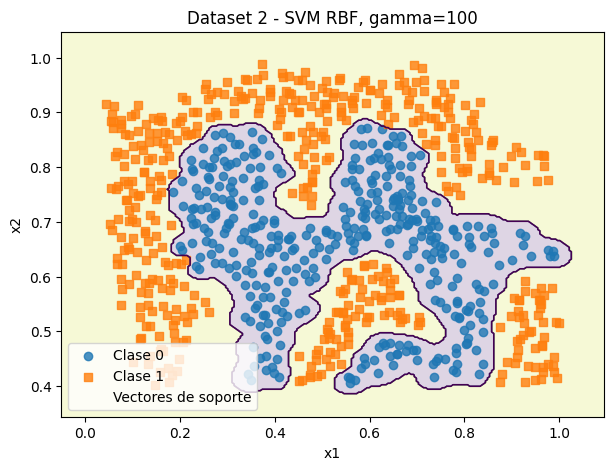

In [18]:
valores_gamma = [0.01, 1, 100]

for gamma in valores_gamma:
  svm_rbf = Pipeline([
      ('scaler', StandardScaler()),
      ('svc', SVC(kernel='rbf', gamma=gamma, C=1))
  ])

  svm_rbf.fit(X_svm2, y_svm2)

  plot_decision_boundary(svm_rbf, X_svm2, y_svm2, f'Dataset 2 - SVM RBF, gamma={gamma}')

**Preguntas de análisis**

1. ¿Qué comportamiento se observa con un $\gamma$ demasiado pequeño?
-  Con un gamma demasiado pequeño (=0.01), vemos que la frontera de decisión es muy suave y rigida. Al tener un $\gamma$ bajo, el radio de influencia de cada vector de soporte es muy grande, lo que impide que el modelo se adapte a la topología completa del dataset (no consigue aislar el grupo de muestras azul de los de color naranja). Es un caso de subajuste de datos (underfitting.)

2. ¿Qué comportamiento se observa con un $\gamma$ demasiado grande?
- Con un gamma demasiado grande (=100), vemos que la frontera de decisión dibuja contornos irregulares alrededor de puntos individuales de entrenamiento. un $\gamma$ alto reduce drasticamente el alcance de influencia de cada muestra, provocando que el modelo memorice el ruido y posiciones especificas de los datos en lugar de aprender el patron real. Esto resulta en un sobreajuste (overfitting).

3. ¿La configuración que obtiene el mayor accuracy de entrenamiento puede considerarse automáticamente la mejor? Justifique.
- No. La SVM con $\gamma$=100 obtendrá el accuracy de entrenamiento mas alto porque su frontera envuelve perfectamente a todos los puntos del set de entrenamiento. Sin embargo, al no poder generalizar, falla gravemente al momento de clasificar los datos nuevos. Lo que se busca es un modelo que se adapte correctamente al patrón y generalice bien ante datos nuevos (como vemos en el caso de $\gamma$=1). Por esta razón, el rendimiento real y la selección del hiperparámetro solo deben determinarse usando un conjunto de validación o mediante validación cruzada.

## Parte C. Selección de hiperparámetros y evaluación final

#### 13. Entrenamiento, validación y prueba

Cuando se entrenan varios modelos o se prueban diferentes hiperparámetros, el conjunto de prueba debe mantenerse completamente separado hasta el final.

Se distinguen tres funciones para los datos:

- **Train:** ajustar los parámetros del modelo.
- **Validation:** comparar configuraciones e hiperparámetros.
- **Test:** realizar una evaluación final del procedimiento elegido.

Si los datos disponibles no permiten reservar una gran fracción para validación, puede utilizarse **validación cruzada** sobre los datos de desarrollo. Aun utilizando validación cruzada, conviene conservar un conjunto de prueba independiente para la evaluación final.

En esta sección se utilizará `data3_train_val_test.mat`, preparado con conjuntos explícitos de entrenamiento, validación y prueba.

Train: (211, 2) [105 106]
Validation: (100, 2) [56 44]
Test: (100, 2) [57 43]


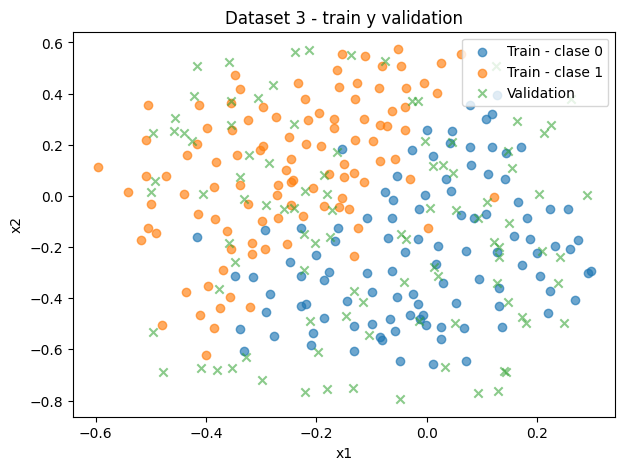

In [19]:
# Código provisto
mat3 = sio.loadmat(DATA_DIR / 'data3_train_val_test.mat')

X_train_3 = mat3['X_train']
y_train_3 = mat3['y_train'].ravel()
X_val_3 = mat3['X_val']
y_val_3 = mat3['y_val'].ravel()
X_test_3 = mat3['X_test']
y_test_3 = mat3['y_test'].ravel()

print('Train:', X_train_3.shape, np.bincount(y_train_3.astype(int)))
print('Validation:', X_val_3.shape, np.bincount(y_val_3.astype(int)))
print('Test:', X_test_3.shape, np.bincount(y_test_3.astype(int)))

plt.figure(figsize=(7, 5))
for label in np.unique(y_train_3):
    plt.scatter(
        X_train_3[y_train_3 == label, 0],
        X_train_3[y_train_3 == label, 1],
        alpha=0.65,
        label=f'Train - clase {label}',
    )
plt.scatter(X_val_3[:, 0], X_val_3[:, 1], marker='x', alpha=0.55, label='Validation')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Dataset 3 - train y validation')
plt.legend()
plt.show()

A partir de la visualización de los conjuntos de entrenamiento y validación, se observa lo siguiente:

* **Frontera curva con solapamiento:** Las clases 0 (azul) y 1 (naranja) se separan aproximadamente por una diagonal curva, con una zona de mezcla en el centro. Una recta ya separa razonablemente bien (en CV sobre train+val, LDA ≈ 0.92 y SVM lineal ≈ 0.93), pero se espera que un modelo no lineal ajuste mejor la curvatura (SVM RBF ≈ 0.95). Por eso conviene explorar C y $\gamma$ con un esquema de validación.

* **Rol del conjunto de Validación (cruces verdes):** Al necesitar un modelo complejo, habrá que ajustar hiperparámetros críticos (ej. C y $\gamma$ en SVM). El conjunto de validación, que se superpone con el entrenamiento, es la herramienta perfecta para evaluar y elegir esa configuración óptima sin contaminar el conjunto de prueba (test).

* **Balance de clases óptimo:** Los datos de entrenamiento están perfectamente balanceados (105 muestras en la clase 0 y 106 en la clase 1), por lo que el algoritmo aprenderá de forma equitativa sin requerir ajustes por desbalance.

#### 14. Selección manual con un único conjunto de validación

Primero se imitará un procedimiento clásico de selección hold-out:

1. entrenar cada combinación de $C$ y $\gamma$ usando **solo train**;
2. medir su accuracy en **validation**;
3. ordenar las configuraciones de mayor a menor desempeño.

Use:

```python
valores_C = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]
valores_gamma = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 300]
```

**Importante:** el escalado debe estar dentro de un `Pipeline`, de modo que cada modelo ajuste el escalador solo con sus datos de entrenamiento.

In [20]:
valores_C = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]
valores_gamma = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 300]

resultados_validacion = []

for C in valores_C:
    for gamma in valores_gamma:
        modelo = Pipeline([
            ('scaler', StandardScaler()),
            ('svc', SVC(kernel='rbf', C=C, gamma=gamma))
        ])

        modelo.fit(X_train_3, y_train_3)

        val_accuracy = modelo.score(X_val_3, y_val_3)

        resultados_validacion.append({
            'C': C,
            'gamma': gamma,
            'validation_accuracy': val_accuracy
        })

In [21]:
# Ordenar resultados de mejor a peor
df_validacion = pd.DataFrame(resultados_validacion)

df_validacion = df_validacion.sort_values(
    by=['validation_accuracy', 'C', 'gamma'],
    ascending=[False, True, True]
).reset_index(drop=True)

print('Mejores configuraciones según validation:')
print(df_validacion.head(15))

mejor_acc_val = df_validacion.loc[0, 'validation_accuracy']

empates_val = df_validacion[
    np.isclose(df_validacion['validation_accuracy'], mejor_acc_val)
]

print(f'\nMejor accuracy de validation: {mejor_acc_val:.4f}')
print(f'Cantidad de configuraciones empatadas: {len(empates_val)}')
print(empates_val)

Mejores configuraciones según validation:
        C  gamma  validation_accuracy
0     0.1    1.0                 0.99
1     0.3    3.0                 0.99
2    30.0    1.0                 0.99
3   100.0    0.3                 0.99
4     0.1    3.0                 0.98
5     0.3    1.0                 0.98
6     1.0    0.3                 0.98
7     1.0    1.0                 0.98
8     1.0    3.0                 0.98
9     1.0   10.0                 0.98
10    3.0    0.3                 0.98
11    3.0    1.0                 0.98
12    3.0    3.0                 0.98
13   10.0    0.3                 0.98
14   10.0    1.0                 0.98

Mejor accuracy de validation: 0.9900
Cantidad de configuraciones empatadas: 4
       C  gamma  validation_accuracy
0    0.1    1.0                 0.99
1    0.3    3.0                 0.99
2   30.0    1.0                 0.99
3  100.0    0.3                 0.99


**Preguntas de análisis**

1. ¿Hay una única combinación ganadora o aparecen empates?
2. Si varias configuraciones obtienen el mismo accuracy de validación, ¿qué problema aparece al elegir una?
3. ¿Podemos utilizar el conjunto de test para desempatar?
4. ¿Qué limitación tiene basar toda la decisión en un único conjunto de validación de 100 muestras?

**1. ¿Hay una única combinación ganadora o aparecen empates?**

No. Según la salida del código, aparecen 4 configuraciones empatadas con el mejor accuracy de validación (0.99): 
* C = 0.1/ $\gamma$ = 1.0 
* C = 0.3/ $\gamma$ = 3.0
* C = 30.0/ $\gamma$ = 1.0
* C = 100.0/ $\gamma$ = 0.3.

**2. Si varias configuraciones obtienen el mismo accuracy de validación, ¿qué problema aparece al elegir una?**

El problema es definir un criterio de desempate que no dependa del azar o la subjetividad del programador. Cuando dos o más modelos tienen un desempeño idéntico, se debe aplicar el principio de parsimonia y elegir el modelo más simple. Priorizar la simplicidad (el modelo con menor costo computacional o mayor margen) garantiza una mayor estabilidad en las predicciones y evita comportamientos impredecibles a futuro.  

**3. ¿Podemos utilizar el conjunto de test para desempatar?**

No. El conjunto de prueba debe mantenerse completamente separado e independiente del proceso de entrenamiento y ajuste. Si lo utilizás para desempatar o elegir hiperparámetros, ocurre una fuga de datos, dado que el conjunto de prueba pierde su independencia y el desempeño que reportes al final será una ficción optimista y falsa.  

**4. ¿Qué limitación tiene basar toda la decisión en un único conjunto de validación de 100 muestras?**

El alto error de varianza, debido a la poca cantidad de datos. Al tener solo 100 muestras el desempeño del modelo puede volverse dependiente de las características exactas de esas observaciones particulares (sobreajuste al set de validación). Si se seleccionaran 100 muestras diferentes, es muy probable que los resultados y la configuración "ganadora" cambien drásticamente.  

#### 15. Validación cruzada para seleccionar hiperparámetros

Ahora se combinarán `train` y `validation` en un conjunto de **train_val**. El conjunto de test seguirá completamente aislado.

Para cada combinación de $C$ y $\gamma$ se calculará el accuracy medio de una validación cruzada de 5 particiones usando `cross_val_score`.

Esto permite que diferentes subconjuntos de `train_val` actúen como validación, reduciendo la dependencia respecto de una única partición.

In [22]:
# Código provisto
X_train_val_3 = np.vstack([X_train_3, X_val_3])
y_train_val_3 = np.concatenate([y_train_3, y_val_3])

print('Train+Val:', X_train_val_3.shape)
print('Test reservado:', X_test_3.shape)

Train+Val: (311, 2)
Test reservado: (100, 2)


In [23]:
resultados_cv=[]

for C in valores_C:
    for gamma in valores_gamma:
        pipe= Pipeline([
            ('Scaler', StandardScaler()),
            ('SVC', SVC(C=C, gamma=gamma, kernel='rbf'))
        ])
        scores= cross_val_score(pipe, X_train_val_3, y_train_val_3, cv=5, scoring='accuracy', n_jobs=1)
        resultados_cv.append((scores.mean(), scores.std(), C, gamma))

resultados_cv.sort(reverse=True, key=lambda x: x[0])
print("Mejores configuraciones (Validacion Cruzada 5-fold):")
for mean_acc, std_acc, C, gamma in resultados_cv[:5]:
    print(f"Acc medio: {mean_acc:.4f} (+/- {std_acc:.4f} | C: {C} | gamma: {gamma})")

Mejores configuraciones (Validacion Cruzada 5-fold):
Acc medio: 0.9520 (+/- 0.0362 | C: 100 | gamma: 0.3)
Acc medio: 0.9487 (+/- 0.0338 | C: 0.3 | gamma: 3)
Acc medio: 0.9487 (+/- 0.0353 | C: 1 | gamma: 1)
Acc medio: 0.9455 (+/- 0.0326 | C: 1 | gamma: 3)
Acc medio: 0.9455 (+/- 0.0326 | C: 1 | gamma: 10)


**Preguntas de análisis**

1. ¿La mejor combinación obtenida con validación cruzada coincide necesariamente con alguna de las mejores del hold-out validation?
- No necesariamente. El hold-out usa una única partición de 100 muestras y la CV cinco particiones de train_val, así que pueden ordenar las configuraciones de forma distinta. En este casp sí hubo coincidencia: la mejor por CV (C = 100, $\gamma$ = 0.3, accuracy medio 0.9520) es una de las 4 configuraciones empatadas en 0.99 en el hold-out. Pero las otras tres empatadas no quedan en el top de la CV: solo C = 0.3, $\gamma$ = 3 aparece entre las mejores (0.9487), y las de C = 0.1, $\gamma$ = 1 y C = 30, $\gamma$ = 1 quedan por debajo del top 5. El hold-out no lograba distinguirlas y la CV sí.

2. ¿Por qué el mejor accuracy medio de CV puede ser menor que el obtenido con hold-out?
- Porque el accuracy del hold-out puede ser engañosamente optimista. Si por azar el conjunto de validación único resultó "fácil" de clasificar, la métrica se infla artificialmente. La validación cruzada expone al modelo a variaciones en los datos, por lo que su promedio devuelve una estimación más conservadora y realista de la verdadera capacidad de generalización del clasificador.

3. ¿Qué información adicional aporta `cv_std`?
- Mide la estabilidad del modelo. Refleja qué tanto varió el accuracy entre los 5 folds. Si dos configuraciones tienen un accuracy medio casi idéntico (como en el caso 2 y 3 con acc_medio=0.9487), se puede desempatar eligiendo la que tiene una menor desviación estándar. Un cv_std bajo garantiza que el modelo no depende de datos afortunados para rendir bien, sino que es consistente.

#### 16. Automatización con `GridSearchCV`

`GridSearchCV` automatiza el procedimiento anterior:

- genera todas las combinaciones del diccionario `param_grid`
- evalúa cada combinación mediante validación cruzada
- selecciona la configuración con mejor score medio
- vuelve a ajustar el mejor pipeline utilizando todos los datos del conjunto train_val cuando `refit=True`.

**Consigna.** Repita la búsqueda anterior con `GridSearchCV` y compare los resultados con la búsqueda manual.

**¿Llega al mismo resultado?**

In [24]:
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf'))
])

param_grid = {
    'svc__C': valores_C,
    'svc__gamma': valores_gamma,
}

grid_search = GridSearchCV(estimator=pipeline_svm, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=1)
grid_search.fit(X_train_val_3, y_train_val_3)

print('Mejores hiperparámetros por GridSearchCV:', grid_search.best_params_)
print(f'Mejor accuracy medio en CV: {grid_search.best_score_:.4f}')


Mejores hiperparámetros por GridSearchCV: {'svc__C': 100, 'svc__gamma': 0.3}
Mejor accuracy medio en CV: 0.9520


**¿Llega al mismo resultado?**
- Sí. GridSearchCV selecciona C = 100 y $\gamma$ = 0.3 con un accuracy medio de 0.9520, igual que la mejor configuración de la búsqueda manual. Es lo esperable, ambas evalúan las mismas combinaciones con el mismo Pipeline y con cv=5. En clasificación, un entero en `cv` equivale a StratifiedKFold sin mezclar, por lo que los folds son idénticos y cada score coincide.


#### 17. Evaluación final sobre test

Hasta este punto, el conjunto `X_test_3, y_test_3` no se utilizó para elegir hiperparámetros. Recién ahora se empleará para estimar el desempeño final del mejor modelo seleccionado.

**Consigna.** Evalúe `grid_search.best_estimator_` sobre test, muestre la matriz de confusión y grafique la frontera de decisión.

Use la función `plot_decision_boundary` provista al inicio de la notebook

Accuracy en test: 0.9300


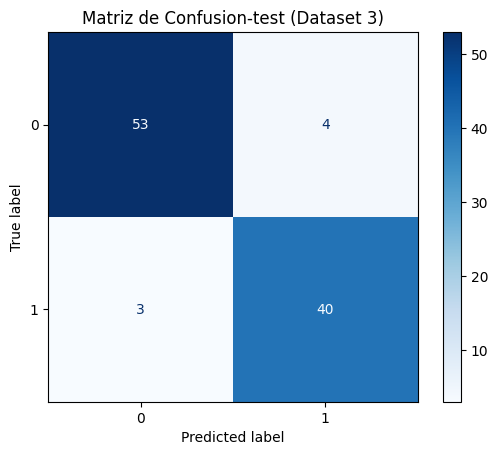

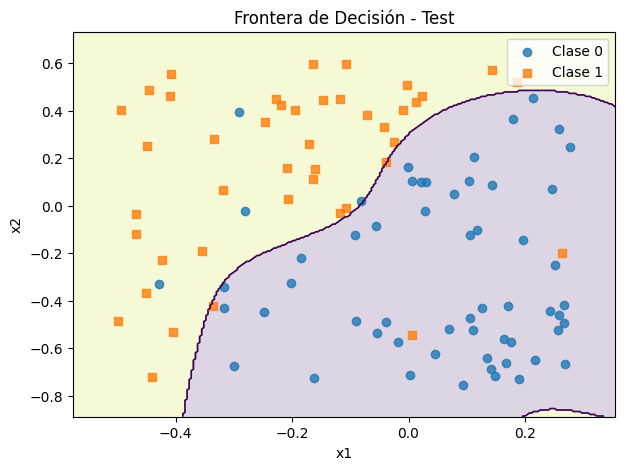

In [25]:
mejor_modelo = grid_search.best_estimator_
y_pred_test_3 = mejor_modelo.predict(X_test_3)
print(f"Accuracy en test: {accuracy_score(y_test_3, y_pred_test_3):.4f}")
cm_3 = confusion_matrix(y_test_3, y_pred_test_3)

ConfusionMatrixDisplay(confusion_matrix=cm_3).plot(cmap='Blues')
plt.title('Matriz de Confusion-test (Dataset 3)')
plt.show()

# Graficamos la frontera de decisión sobre el conjunto de test
# Desactivamos show_support porque los vectores de soporte solo existen en los datos de entrenamiento
plot_decision_boundary(
    mejor_modelo, 
    X_test_3, 
    y_test_3, 
    'Frontera de Decisión - Test', 
    show_support=False
)

**Preguntas de análisis**

1. ¿Por qué el test debe utilizarse recién después de finalizar la selección de hiperparámetros?
- Se usa al finalizar porque asegura que la metrica obtenida sea una evaluacion genuina y que no este sesgada por el proceso de sintonización de hiperparámetros.

2. ¿Qué ocurriría si, al ver el resultado de test, modificáramos nuevamente $C$ o $\gamma$ para mejorarlo?
- Si se ajustasen los parametros luego de observar el resultado de test, este dejearia de ser un conjunto de prueba independiente y se contaminaría todo el proceso de validación.

## Parte D. Comparar LDA y SVM sobre el mismo problema

Volvamos al Wine dataset. Utilice la misma partición que usó al inicio (train + test).

El objetivo es comparar modelos utilizando **la misma estrategia de evaluación**, evitando comparar scores obtenidos bajo procedimientos distintos.

Se considerarán tres clasificadores:

- LDA
- SVM lineal
- SVM con kernel RBF.

LDA se evaluará por validación cruzada. Para las SVM, los hiperparámetros se seleccionarán con `GridSearchCV` sobre el mismo conjunto de entrenamiento. El conjunto de prueba de Wine seguirá reservado hasta seleccionar el mejor candidato según CV.

#### 18. Comparación de clasificadores

**Consigna.** Sobre `X_train, y_train`:

1. estime el desempeño de LDA con `cross_val_score(cv=5)`;
2. seleccione $C$ para SVM lineal mediante `GridSearchCV`;
3. seleccione $C$ y $\gamma$ para SVM RBF mediante `GridSearchCV`;
4. compare los mejores scores medios de validación cruzada.

In [26]:
# LDA: estimación por validación cruzada
lda_wine = LinearDiscriminantAnalysis()

scores_lda_wine = cross_val_score(lda_wine, X_train, y_train, cv=5, scoring='accuracy')

lda_cv_mean = scores_lda_wine.mean()
lda_cv_std = scores_lda_wine.std()

# SVM lineal: seleccionar C con GridSearchCV
pipe_svm_lineal = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='linear'))
])

grid_lineal = GridSearchCV(estimator=pipe_svm_lineal, param_grid={'svc__C': valores_C}, cv=5, scoring='accuracy', n_jobs=1, refit=True)

grid_lineal.fit(X_train, y_train)

# SVM RBF: seleccionar C y gamma con GridSearchCV
pipe_svm_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf'))
])

grid_rbf = GridSearchCV( estimator=pipe_svm_rbf, param_grid={'svc__C': valores_C, 'svc__gamma': valores_gamma}, cv=5, scoring='accuracy', n_jobs=1, refit=True)

grid_rbf.fit(X_train, y_train)

# Comparación
comparacion_modelos = pd.DataFrame({
    'modelo': [
        'LDA',
        'SVM lineal',
        'SVM RBF'
    ],
    'cv_mean': [
        lda_cv_mean,
        grid_lineal.best_score_,
        grid_rbf.best_score_
    ],
    'cv_std': [
        lda_cv_std,
        grid_lineal.cv_results_['std_test_score'][grid_lineal.best_index_],
        grid_rbf.cv_results_['std_test_score'][grid_rbf.best_index_]
    ]
}).sort_values('cv_mean', ascending=False).reset_index(drop=True)

print('Resultados de validación cruzada:')
print(comparacion_modelos)

print('\nMejor C para SVM lineal:')
print(grid_lineal.best_params_)

print('\nMejores parámetros para SVM RBF:')
print(grid_rbf.best_params_)

print('\nModelo con mejor score medio de CV:')
print(comparacion_modelos.iloc[0])

Resultados de validación cruzada:
       modelo   cv_mean    cv_std
0     SVM RBF  0.992000  0.016000
1         LDA  0.984000  0.019596
2  SVM lineal  0.983667  0.020011

Mejor C para SVM lineal:
{'svc__C': 0.1}

Mejores parámetros para SVM RBF:
{'svc__C': 1, 'svc__gamma': 0.1}

Modelo con mejor score medio de CV:
modelo     SVM RBF
cv_mean      0.992
cv_std       0.016
Name: 0, dtype: object


**¿Qué modelo obtiene el mejor score medio de CV en esta ejecución?**

**Comparación de clasificadores**

Al evaluar los tres modelos bajo la misma estrategia de validación cruzada, el modelo ganador es la SVM con kernel RBF, ya que logra el accuracy medio más alto de los tres.

* SVM RBF (1° lugar): Alcanzó un score medio de 0.992 (99.2%) y una desviación estándar muy baja de 0.016. Los mejores hiperparámetros encontrados por la búsqueda en grilla fueron C = 1 y $\gamma$ = 0.1. La diferencia con LDA (0.992 vs 0.984) equivale a una sola muestra de las 124 de entrenamiento, y 9 de las 81 configuraciones RBF alcanzan el mismo 0.992 (GridSearchCV elige la primera de la grilla), por lo que es prácticamente un empate.
* LDA (2° lugar): Con un score medio de 0.984 (98.4%) y una desviación estándar de 0.019. Está en segundo lugar pero tiene la gran ventaja de ser un modelo más simple que no requiere la búsqueda y ajuste de hiperparámetros externos para entrenarse.
* SVM Lineal (3° lugar): Prácticamente empatado con LDA, obteniendo un score medio de 0.983 (98.3%) y una desviación de 0.020. Su mejor hiperparámetro de penalización fue C = 0.1.

**Conclusión:** La SVM RBF es el que obtiene el mayor score medio, aunque por una diferencia mínima. Además, LDA y la SVM Lineal obtuvieron resultados casi idénticos (0.984 y 0.983). Esto es completamente consistente a nivel matemático, ya que ambos algoritmos intentan resolver el problema trazando fronteras de decisión lineales, por lo cual estarían chocando con el mismo límite de precisión.

#### 19. Evaluación del modelo seleccionado en Wine

Seleccione el candidato con mejor score de validación cruzada y evalúelo **una sola vez** sobre el test reservado al comienzo.

**Comente el resultado**

Modelo seleccionado: SVM con kernel RBF
Accuracy final en test: 0.9815

Reporte de clasificación:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       0.95      1.00      0.98        21
     class_2       1.00      0.93      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



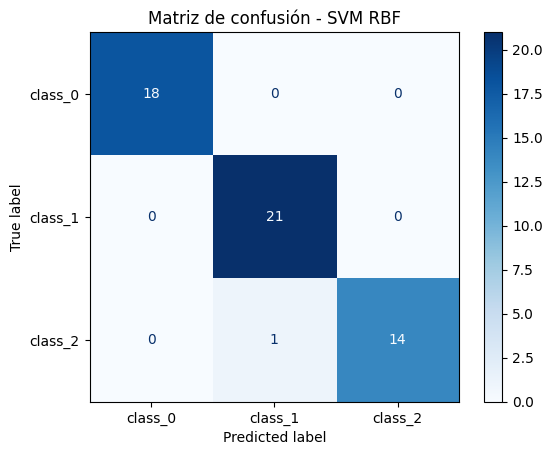

In [27]:
modelo_final_wine = grid_rbf.best_estimator_

# Se evalúa sobre el test reservado
y_pred_final_wine = modelo_final_wine.predict(X_test)

acc_final_wine = accuracy_score(y_test, y_pred_final_wine)
cm_final_wine = confusion_matrix(y_test, y_pred_final_wine)

print('Modelo seleccionado: SVM con kernel RBF')
print(f'Accuracy final en test: {acc_final_wine:.4f}')

print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred_final_wine, target_names=class_names))

ConfusionMatrixDisplay(confusion_matrix=cm_final_wine, display_labels=class_names).plot(cmap='Blues')
plt.title('Matriz de confusión - SVM RBF')
plt.show()

El modelo seleccionado (SVM con kernel RBF) demostró un muy buen desempeño sobre el conjunto de prueba, alcanzando un accuracy del 98.15% (la tasa de aciertos sobre el total de instancias evaluadas), consistente con el 0.992 obtenido durante la validación cruzada.
* **Tasa de error mínima:** El modelo logró clasificar correctamente 53 de las 54 muestras del conjunto reservado. El único error de toda la evaluación consistió en un vino de la clase 2 que fue predicho incorrectamente como clase 1.
* **Clase 0:** El modelo identifica esta categoría con total seguridad, logrando métricas perfectas (1.00) tanto en precision como en recall.
* **Clase 1 (Alta sensibilidad):** Obtuvo un recall de 1.00, lo que indica que el algoritmo logró detectar el 100% de los casos reales positivos para esta categoría. Sin embargo, su precision bajó a 0.95 justamente por haber absorbido el falso positivo de la clase 2.
* **Clase 2 (Alta precisión):** Presenta el escenario inverso. Su precision se mantuvo en 1.00 porque ninguna otra muestra fue clasificada erróneamente hacia esta categoría, pero su recall cayó a 0.93 al haber dejado escapar una de sus muestras reales hacia la clase 1.

El conjunto de prueba tiene solo 54 datos. Si el modelo se equivoca en un solo dato, su porcentaje de acierto baja casi un 2%. Ganarle a otro modelo por uno o dos puntos en una muestra tan chica suele ser pura suerte estadística, no una ventaja real del algoritmo. Entonces, durante la validación cruzada (secciones 18 y 20), los modelos lineales sacaron prácticamente la misma nota que la SVM RBF y no se puede afirmar con total seguridad que sea mejor que un modelo lineal.

#### 20. LDA como transformación antes de otro clasificador

LDA también puede colocarse dentro de un `Pipeline` antes de otro clasificador. Esto permite estudiar una secuencia del tipo:

$$
X \rightarrow \text{StandardScaler} \rightarrow \text{LDA} \rightarrow \text{SVM}.
$$

La transformación LDA es **supervisada**, porque utiliza las etiquetas $y$. Por eso, si se evalúa mediante validación cruzada, LDA debe ajustarse **dentro de cada fold**. Ajustar LDA sobre todo el dataset y luego hacer CV sobre la representación transformada produciría fuga de información.

**Consigna** 

Evalúe el pipeline `Scaler → LDA(n_components=2) → SVM lineal` con validación cruzada.

Compare con los resultados de los modelos en 19 y comente el resultado

In [28]:
# Pipeline: StandardScaler -> LDA -> SVM lineal
pipeline_lda_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('lda', LinearDiscriminantAnalysis(n_components=2)),
    ('svc', SVC(kernel='linear', C=1))
])

scores_lda_svm = cross_val_score(pipeline_lda_svm, X_train, y_train, cv=5, scoring='accuracy')

print('Scores Scaler -> LDA -> SVM lineal:')
print(scores_lda_svm)

print(f'Media CV: {scores_lda_svm.mean():.4f}')
print(f'Std CV: {scores_lda_svm.std():.4f}')

print('\nComparación con los modelos anteriores:')
print(comparacion_modelos)

print(f'\nPipeline LDA + SVM lineal -> ' f'media={scores_lda_svm.mean():.4f}, ' f'std={scores_lda_svm.std():.4f}')

Scores Scaler -> LDA -> SVM lineal:
[0.96 1.   1.   1.   1.  ]
Media CV: 0.9920
Std CV: 0.0160

Comparación con los modelos anteriores:
       modelo   cv_mean    cv_std
0     SVM RBF  0.992000  0.016000
1         LDA  0.984000  0.019596
2  SVM lineal  0.983667  0.020011

Pipeline LDA + SVM lineal -> media=0.9920, std=0.0160


El pipeline StandardScaler → LDA(2) → SVM lineal obtiene un accuracy medio de CV de 0.9920 (± 0.0160), igual que la SVM RBF (0.992 ± 0.016) y levemente superior a LDA solo (0.984 ± 0.0196) y a la SVM lineal (0.9837 ± 0.0200).

**Comparación con SVM RBF (Actividad 19)**

Ambos modelos empatan en CV. La diferencia con LDA (0.992 vs 0.984) equivale a una única muestra de las 124 de entrenamiento, por lo que no alcanza para afirmar que un modelo sea mejor que otro. Tampoco es idéntico a LDA solo: difiere en el segundo fold, donde el pipeline acierta las 25 muestras y LDA falla una.

* **Interpretación:** LDA proyecta a 2 dimensiones las direcciones que mejor separan las clases, y sobre ese espacio una SVM lineal alcanza el mismo desempeño que RBF. En Wine no hace falta una frontera no lineal: las clases ya son casi separables linealmente (LDA solo llega a 98.4%).
* **Cautela:** la SVM del pipeline usa C = 1 sin ajustar, y con 124 muestras las diferencias de una muestra son ruido. El test ya se usó una vez en la sección 19, así que no se reutiliza para desempatar.